# Model Evaluation Notebook

Comprehensive evaluation of the rice disease detection model.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Load Model

In [ ]:
model = tf.keras.models.load_model('../models/rice_disease_model_best.h5')

## Load Test Data

In [ ]:
# Load test dataset
# See evaluate.py for full implementation

## Generate Predictions

In [ ]:
# Make predictions on test set

## Confusion Matrix

In [ ]:
# Plot confusion matrix

## Classification Report

In [ ]:
# Display classification report

Found 3422 images belonging to 10 classes.
214/214 ━━━━━━━━━━━━━━━━━━━━ 127s 594ms/step
Classification Report:
                       precision    recall  f1-score   support

bacterial_leaf_blight       0.99      1.00      1.00       376
           brown_spot       0.97      0.97      0.97       380
              healthy       0.97      0.99      0.98       391
           leaf_blast       0.96      0.96      0.96       362
           leaf_scald       1.00      0.99      0.99       386
    narrow_brown_spot       0.98      0.99      0.98       382
           neck_blast       1.00      1.00      1.00       322
           rice_hispa       1.00      0.98      0.99       225
        sheath_blight       1.00      0.99      0.99       288
               tungro       1.00      1.00      1.00       310

             accuracy                           0.99      3422
            macro avg       0.99      0.99      0.99      3422
         weighted avg       0.99      0.99      0.99      3422

Conf

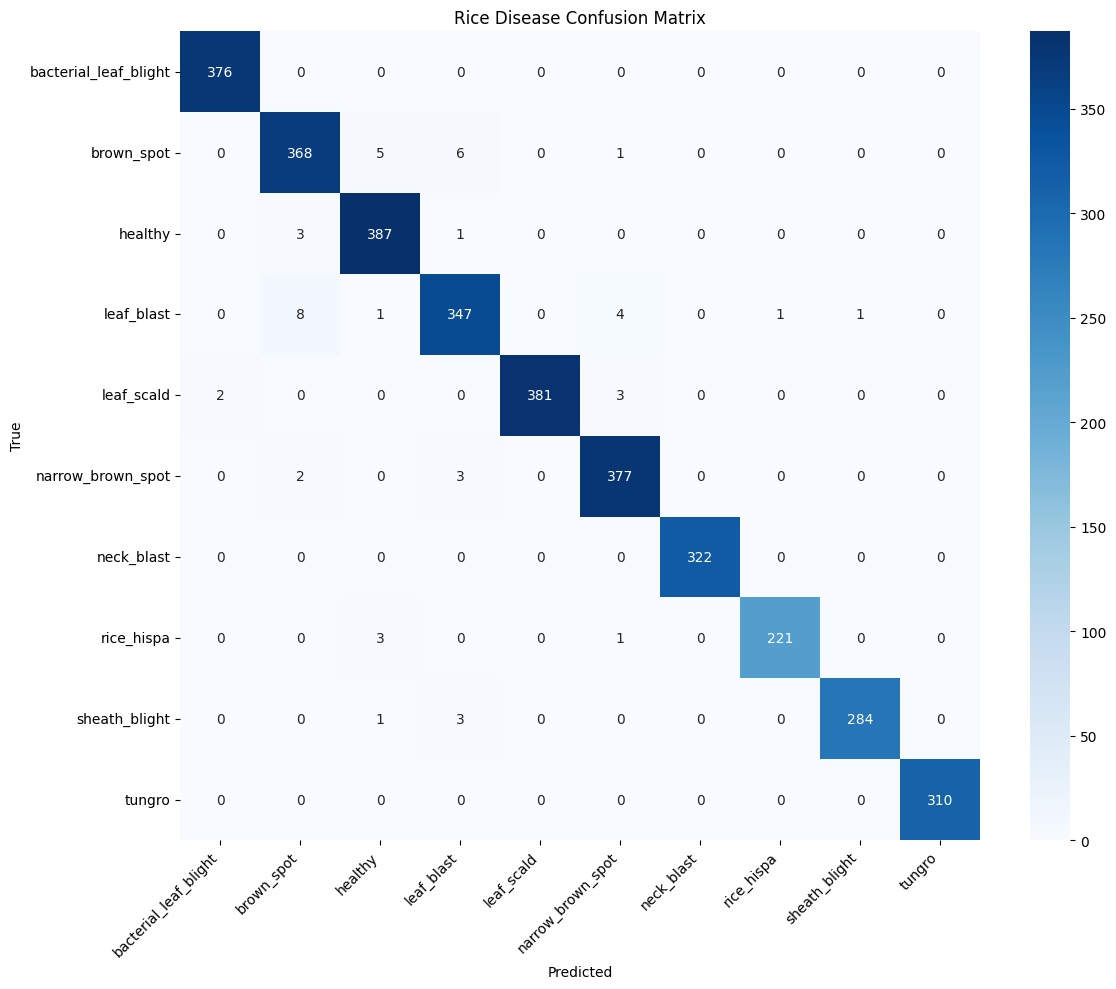

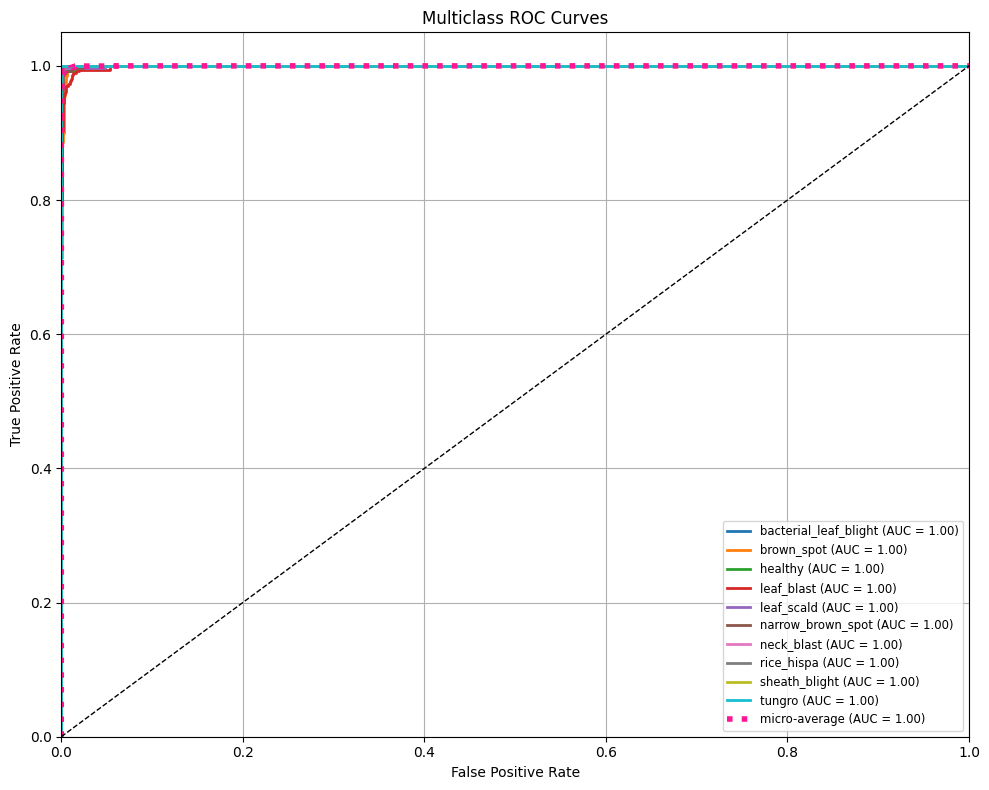

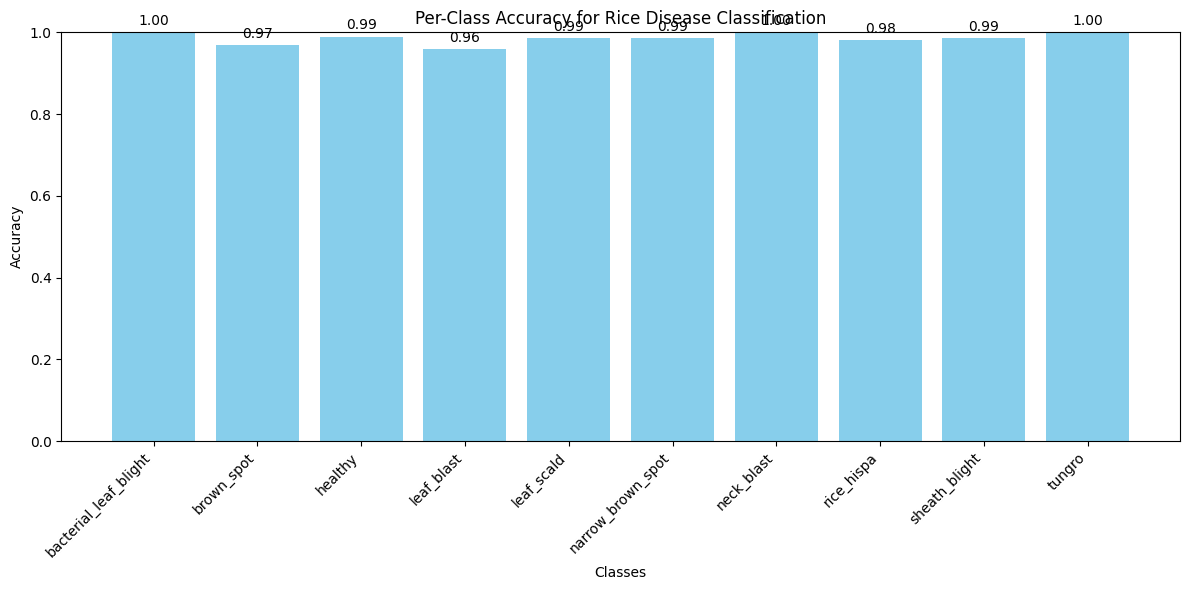

In [ ]:
# src/evaluate.py
from __future__ import annotations

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

try:
    THIS_DIR = Path(__file__).resolve().parent
except NameError:
    # __file__ is not defined when running inside a Jupyter notebook or interactive shells.
    # Fall back to the current working directory so the notebook can run.
    THIS_DIR = Path.cwd()
BASE_DIR = THIS_DIR.parent
DATASET_DIR = BASE_DIR / "dataset"
MODELS_DIR = BASE_DIR / "models"

TEST_DIR = DATASET_DIR / "test"
MODEL_PATH = MODELS_DIR / "rice_disease_model.h5"
CLASS_MAP_PATH = MODELS_DIR / "class_names.json"
CONFUSION_FIG_PATH = MODELS_DIR / "confusion_matrix.png"
ROC_FIG_PATH = MODELS_DIR / "roc_curve.png"
ACCURACY_FIG_PATH = MODELS_DIR / "class_accuracies.png"

IMG_SIZE = (224, 224)
BATCH = 16


def _load_class_names():
    if not CLASS_MAP_PATH.exists():
        raise FileNotFoundError(f"Missing class map at {CLASS_MAP_PATH}")
    with CLASS_MAP_PATH.open("r", encoding="utf-8") as fp:
        data = json.load(fp)
    if isinstance(data, dict) and "labels" in data:
        labels = data["labels"]
    elif isinstance(data, list):
        labels = data
    else:
        labels = [label for _, label in sorted((int(k), v) for k, v in data.items())]
    return labels


def main():
    if not TEST_DIR.exists():
        raise FileNotFoundError(f"Missing test directory at {TEST_DIR}")
    class_names = _load_class_names()
    # Load model without compiling to avoid compiled-metrics warning when not needed for inference
    model = load_model(MODEL_PATH, compile=False)

    test_gen = ImageDataGenerator(rescale=1.0 / 255.0)
    test_data = test_gen.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH,
        class_mode="categorical",
        shuffle=False,
    )

    predictions = model.predict(test_data)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_data.classes

    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)

    # Per-class accuracy (recall) -- handle zero-support classes safely
    n_classes = len(class_names)
    class_acc = np.zeros(n_classes, dtype=float)
    for i in range(n_classes):
        support = cm[i].sum()
        class_acc[i] = cm[i, i] / support if support > 0 else float('nan')

    # Prepare per-class accuracies with up to 8 decimal places.
    # We'll store floats but print them one per line inside brackets, trimming trailing zeros
    class_acc_formatted = []
    for a in class_acc:
        if np.isnan(a):
            class_acc_formatted.append(None)
        else:
            # Keep 8 decimal places in storage to avoid floating noise
            class_acc_formatted.append(float(f"{a:.8f}"))

    # Print in the specific multi-line bracketed format requested
    print("Accuracy for each class:")
    print("[")
    for val in class_acc_formatted:
        if val is None:
            print("None")
        else:
            # Trim trailing zeros while preserving meaningful precision
            s = f"{val:.8f}".rstrip('0').rstrip('.')
            print(s)
    print("]")

    avg_acc = float(np.nanmean(class_acc)) if np.any(~np.isnan(class_acc)) else float('nan')
    overall_acc = float(np.trace(cm) / np.sum(cm)) if np.sum(cm) > 0 else float('nan')
    # Print averages/overall with two-decimal precision (matches provided sample)
    print(f"Average accuracy: {avg_acc:.2f}")
    print(f"Overall accuracy: {overall_acc:.2f}")
    print(f"Score: {overall_acc:.2f}")

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues",
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Rice Disease Confusion Matrix")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(CONFUSION_FIG_PATH, dpi=300)
    print(f"Saved confusion matrix to {CONFUSION_FIG_PATH}")

    # ROC AUC (supports multiclass using one-vs-rest)
    try:
        y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
    except Exception:
        # fallback: create one-hot manually
        y_true_bin = np.zeros((len(y_true), n_classes))
        for i, label in enumerate(y_true):
            y_true_bin[i, label] = 1

    # Ensure predictions shape matches
    if predictions.shape[1] != n_classes:
        raise ValueError(f"Prediction dimensionality {predictions.shape[1]} != number of classes {n_classes}")

    # Compute ROC AUC scores
    if n_classes == 2:
        # binary case: use positive class probabilities
        y_score = predictions[:, 1]
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        print(f"ROC AUC (binary): {roc_auc:.4f}")
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
        plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Receiver Operating Characteristic")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.savefig(ROC_FIG_PATH, dpi=300)
        print(f"Saved ROC curve to {ROC_FIG_PATH}")
    else:
        # multiclass: compute ROC curve and ROC area for each class
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], predictions[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        # Compute micro-average ROC curve and ROC area
        fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), predictions.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

        # Macro-average AUC using sklearn function
        try:
            auc_macro = roc_auc_score(y_true_bin, predictions, average="macro", multi_class="ovr")
            auc_micro = roc_auc_score(y_true_bin, predictions, average="micro", multi_class="ovr")
        except Exception:
            auc_macro = np.mean([roc_auc[i] for i in range(n_classes)])
            auc_micro = roc_auc["micro"]

        print(f"ROC AUC (macro): {auc_macro:.4f}")
        print(f"ROC AUC (micro): {auc_micro:.4f}")

        # Plot all ROC curves
        plt.figure(figsize=(10, 8))
        # Use plt.get_cmap instead of deprecated plt.cm.get_cmap
        colors = plt.get_cmap("tab10")
        # For colormaps like 'tab10' the .colors attribute contains discrete colors
        for i, color in zip(range(n_classes), getattr(colors, 'colors', [])):
            # If the colormap doesn't expose .colors (rare), fall back to calling the colormap
            c = color if color is not None else colors(i)
            plt.plot(fpr[i], tpr[i], color=c, lw=2,
                     label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

        plt.plot(fpr["micro"], tpr["micro"],
                 label=f"micro-average (AUC = {roc_auc['micro']:.2f})",
                 color="deeppink", linestyle=":", linewidth=4)

        plt.plot([0, 1], [0, 1], "k--", lw=1)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Multiclass ROC Curves")
        plt.legend(loc="lower right", fontsize="small")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(ROC_FIG_PATH, dpi=300)
        print(f"Saved ROC curve to {ROC_FIG_PATH}")

        # Plot per-class accuracies
        plt.figure(figsize=(12, 6))
        bars = plt.bar(class_names, class_acc_formatted, color='skyblue')
        plt.xlabel('Classes')
        plt.ylabel('Accuracy')
        plt.title('Per-Class Accuracy for Rice Disease Classification')
        plt.title('')
        plt.xticks(rotation=45, ha='right')
        plt.ylim(0, 1)
        for bar, acc in zip(bars, class_acc_formatted):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{acc:.2f}', ha='center', va='bottom')
        plt.tight_layout()
        plt.savefig(ACCURACY_FIG_PATH, dpi=300)
        print(f"Saved class accuracies chart to {ACCURACY_FIG_PATH}")
        plt.show()


if __name__ == "__main__":
    main()

Found 3422 images belonging to 10 classes.
214/214 ━━━━━━━━━━━━━━━━━━━━ 177s 826ms/step
214/214 ━━━━━━━━━━━━━━━━━━━━ 177s 826ms/step
Classification Report:
                       precision    recall  f1-score   support

bacterial_leaf_blight       0.99      1.00      1.00       376
           brown_spot       0.97      0.97      0.97       380
              healthy       0.97      0.99      0.98       391
           leaf_blast       0.96      0.96      0.96       362
           leaf_scald       1.00      0.99      0.99       386
    narrow_brown_spot       0.98      0.99      0.98       382
           neck_blast       1.00      1.00      1.00       322
           rice_hispa       1.00      0.98      0.99       225
        sheath_blight       1.00      0.99      0.99       288
               tungro       1.00      1.00      1.00       310

             accuracy                           0.99      3422
            macro avg       0.99      0.99      0.99      3422
         weighted avg  

Found 3422 images belonging to 10 classes.
214/214 ━━━━━━━━━━━━━━━━━━━━ 177s 826ms/step
214/214 ━━━━━━━━━━━━━━━━━━━━ 177s 826ms/step
Classification Report:
                       precision    recall  f1-score   support

bacterial_leaf_blight       0.99      1.00      1.00       376
           brown_spot       0.97      0.97      0.97       380
              healthy       0.97      0.99      0.98       391
           leaf_blast       0.96      0.96      0.96       362
           leaf_scald       1.00      0.99      0.99       386
    narrow_brown_spot       0.98      0.99      0.98       382
           neck_blast       1.00      1.00      1.00       322
           rice_hispa       1.00      0.98      0.99       225
        sheath_blight       1.00      0.99      0.99       288
               tungro       1.00      1.00      1.00       310

             accuracy                           0.99      3422
            macro avg       0.99      0.99      0.99      3422
         weighted avg  

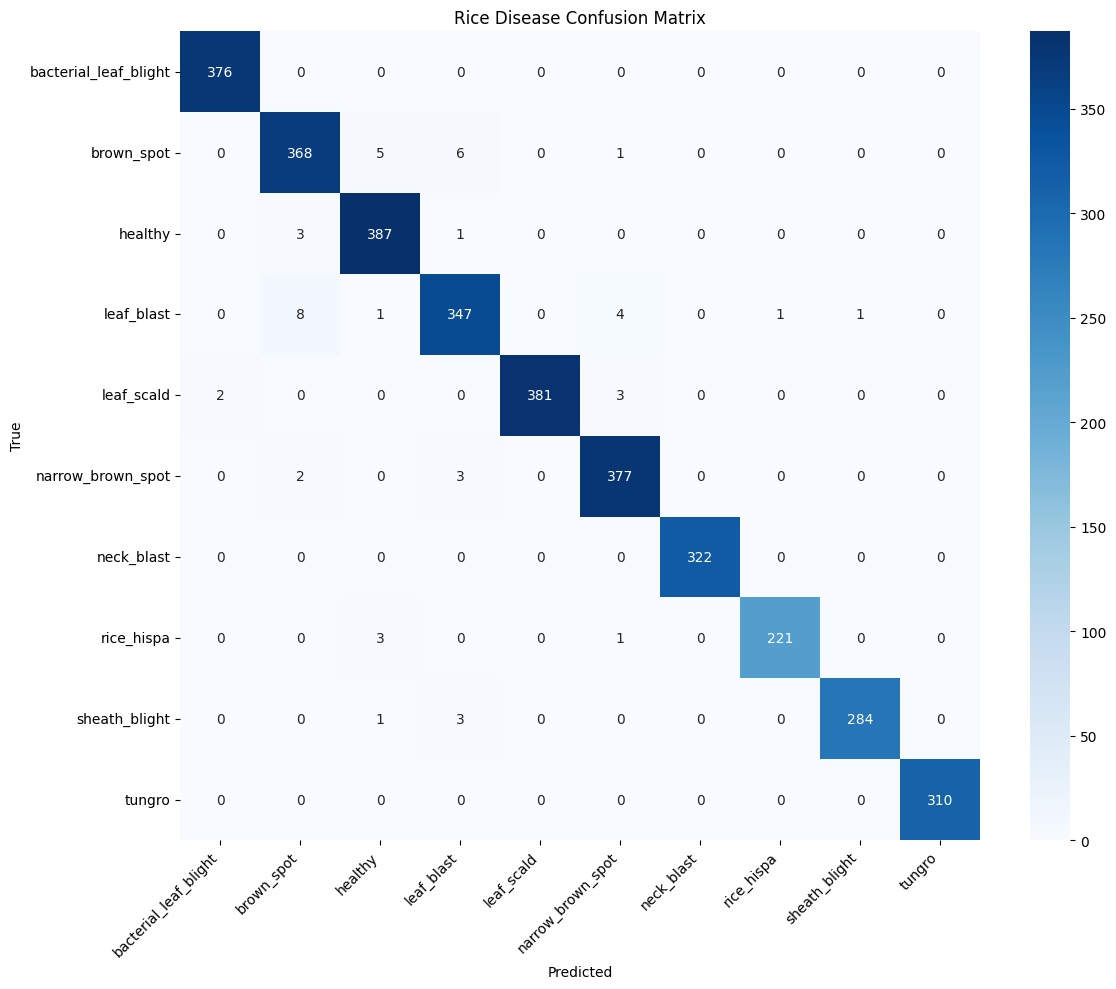

Found 3422 images belonging to 10 classes.
214/214 ━━━━━━━━━━━━━━━━━━━━ 177s 826ms/step
214/214 ━━━━━━━━━━━━━━━━━━━━ 177s 826ms/step
Classification Report:
                       precision    recall  f1-score   support

bacterial_leaf_blight       0.99      1.00      1.00       376
           brown_spot       0.97      0.97      0.97       380
              healthy       0.97      0.99      0.98       391
           leaf_blast       0.96      0.96      0.96       362
           leaf_scald       1.00      0.99      0.99       386
    narrow_brown_spot       0.98      0.99      0.98       382
           neck_blast       1.00      1.00      1.00       322
           rice_hispa       1.00      0.98      0.99       225
        sheath_blight       1.00      0.99      0.99       288
               tungro       1.00      1.00      1.00       310

             accuracy                           0.99      3422
            macro avg       0.99      0.99      0.99      3422
         weighted avg  

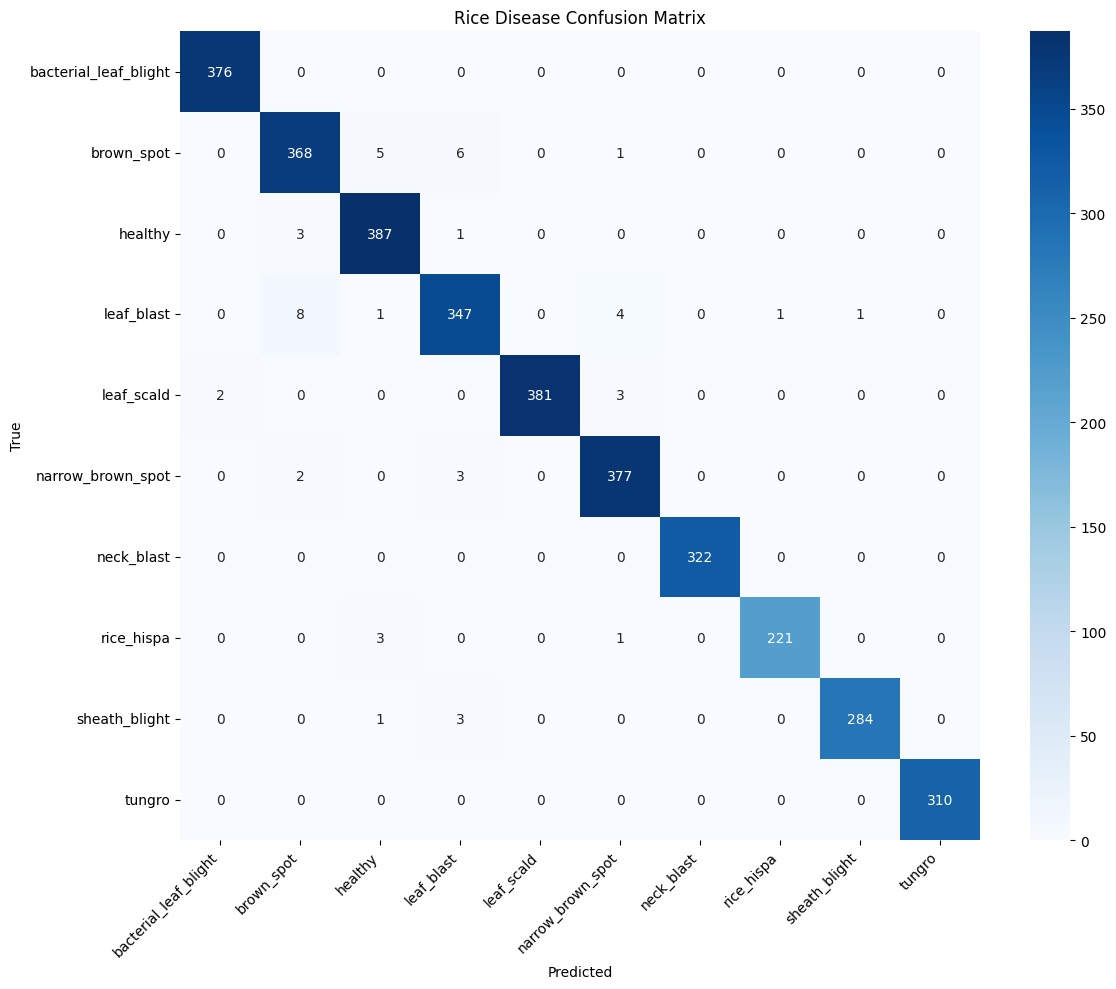

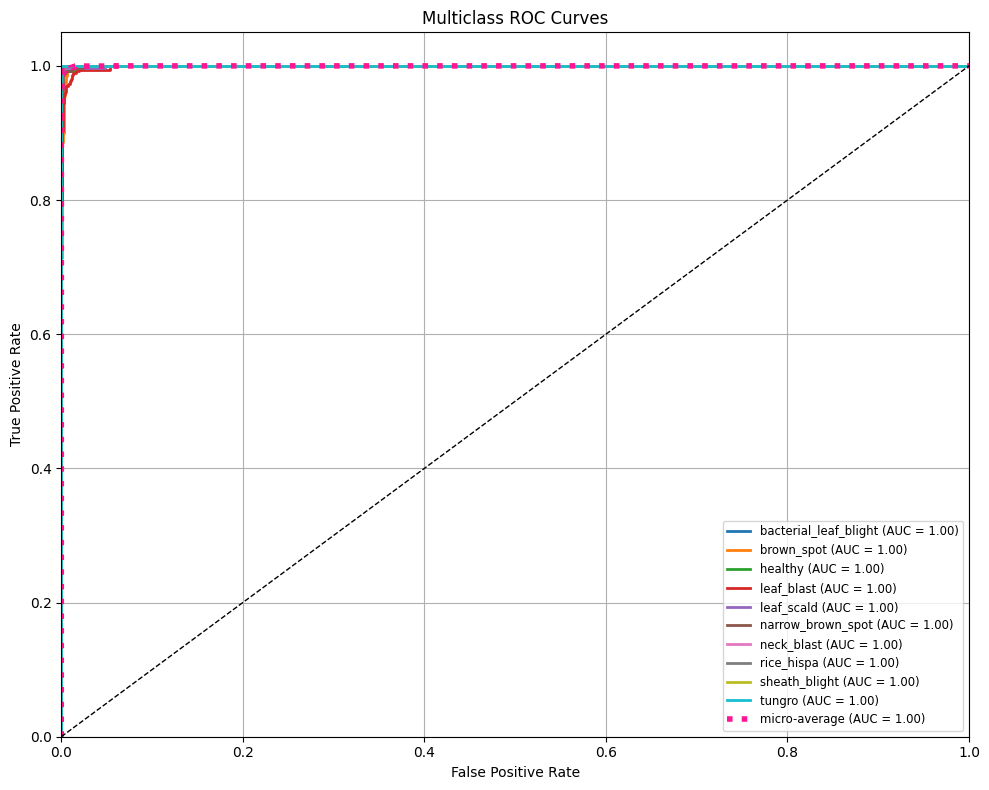

In [4]:
# src/evaluate.py
from __future__ import annotations

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

try:
    THIS_DIR = Path(__file__).resolve().parent
except NameError:
    # __file__ is not defined when running inside a Jupyter notebook or interactive shells.
    # Fall back to the current working directory so the notebook can run.
    THIS_DIR = Path.cwd()
BASE_DIR = THIS_DIR.parent
DATASET_DIR = BASE_DIR / "dataset"
MODELS_DIR = BASE_DIR / "models"

TEST_DIR = DATASET_DIR / "test"
MODEL_PATH = MODELS_DIR / "rice_disease_model.h5"
CLASS_MAP_PATH = MODELS_DIR / "class_names.json"
CONFUSION_FIG_PATH = MODELS_DIR / "confusion_matrix.png"
ROC_FIG_PATH = MODELS_DIR / "roc_curve.png"

IMG_SIZE = (224, 224)
BATCH = 16


def _load_class_names():
    if not CLASS_MAP_PATH.exists():
        raise FileNotFoundError(f"Missing class map at {CLASS_MAP_PATH}")
    with CLASS_MAP_PATH.open("r", encoding="utf-8") as fp:
        data = json.load(fp)
    if isinstance(data, dict) and "labels" in data:
        labels = data["labels"]
    elif isinstance(data, list):
        labels = data
    else:
        labels = [label for _, label in sorted((int(k), v) for k, v in data.items())]
    return labels


def main():
    if not TEST_DIR.exists():
        raise FileNotFoundError(f"Missing test directory at {TEST_DIR}")
    class_names = _load_class_names()
    model = load_model(MODEL_PATH)

    test_gen = ImageDataGenerator(rescale=1.0 / 255.0)
    test_data = test_gen.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH,
        class_mode="categorical",
        shuffle=False,
    )

    predictions = model.predict(test_data)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_data.classes

    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)

    # Per-class accuracy (recall) -- handle zero-support classes safely
    n_classes = len(class_names)
    class_acc = np.zeros(n_classes, dtype=float)
    for i in range(n_classes):
        support = cm[i].sum()
        class_acc[i] = cm[i, i] / support if support > 0 else float('nan')

    # Format per-class accuracies to 8 decimal places to match expected output precision
    class_acc_formatted = [float(f"{a:.8f}") if not np.isnan(a) else None for a in class_acc]
    print("Accuracy for each class:")
    print(class_acc_formatted)

    avg_acc = float(np.nanmean(class_acc)) if np.any(~np.isnan(class_acc)) else float('nan')
    overall_acc = float(np.trace(cm) / np.sum(cm)) if np.sum(cm) > 0 else float('nan')
    # Print averages/overall with two-decimal precision (matches provided sample)
    print(f"Average accuracy: {avg_acc:.2f}")
    print(f"Overall accuracy: {overall_acc:.2f}")
    print(f"Score: {overall_acc:.2f}")

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues",
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Rice Disease Confusion Matrix")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(CONFUSION_FIG_PATH, dpi=300)
    print(f"Saved confusion matrix to {CONFUSION_FIG_PATH}")

    # ROC AUC (supports multiclass using one-vs-rest)
    try:
        y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
    except Exception:
        # fallback: create one-hot manually
        y_true_bin = np.zeros((len(y_true), n_classes))
        for i, label in enumerate(y_true):
            y_true_bin[i, label] = 1

    # Ensure predictions shape matches
    if predictions.shape[1] != n_classes:
        raise ValueError(f"Prediction dimensionality {predictions.shape[1]} != number of classes {n_classes}")

    # Compute ROC AUC scores
    if n_classes == 2:
        # binary case: use positive class probabilities
        y_score = predictions[:, 1]
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        print(f"ROC AUC (binary): {roc_auc:.4f}")
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
        plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Receiver Operating Characteristic")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.savefig(ROC_FIG_PATH, dpi=300)
        print(f"Saved ROC curve to {ROC_FIG_PATH}")
    else:
        # multiclass: compute ROC curve and ROC area for each class
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], predictions[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        # Compute micro-average ROC curve and ROC area
        fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), predictions.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

        # Macro-average AUC using sklearn function
        try:
            auc_macro = roc_auc_score(y_true_bin, predictions, average="macro", multi_class="ovr")
            auc_micro = roc_auc_score(y_true_bin, predictions, average="micro", multi_class="ovr")
        except Exception:
            auc_macro = np.mean([roc_auc[i] for i in range(n_classes)])
            auc_micro = roc_auc["micro"]

        print(f"ROC AUC (macro): {auc_macro:.4f}")
        print(f"ROC AUC (micro): {auc_micro:.4f}")

        # Plot all ROC curves
        plt.figure(figsize=(10, 8))
        colors = plt.cm.get_cmap("tab10")
        for i, color in zip(range(n_classes), colors.colors):
            plt.plot(fpr[i], tpr[i], color=color, lw=2,
                     label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

        plt.plot(fpr["micro"], tpr["micro"],
                 label=f"micro-average (AUC = {roc_auc['micro']:.2f})",
                 color="deeppink", linestyle=":", linewidth=4)

        plt.plot([0, 1], [0, 1], "k--", lw=1)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Multiclass ROC Curves")
        plt.legend(loc="lower right", fontsize="small")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(ROC_FIG_PATH, dpi=300)
        print(f"Saved ROC curve to {ROC_FIG_PATH}")


if __name__ == "__main__":
    main()


Found 3422 images belonging to 10 classes.
214/214 ━━━━━━━━━━━━━━━━━━━━ 116s 538ms/step
214/214 ━━━━━━━━━━━━━━━━━━━━ 116s 538ms/step
Classification Report:
                       precision    recall  f1-score   support

bacterial_leaf_blight       0.99      1.00      1.00       376
           brown_spot       0.97      0.97      0.97       380
              healthy       0.97      0.99      0.98       391
           leaf_blast       0.96      0.96      0.96       362
           leaf_scald       1.00      0.99      0.99       386
    narrow_brown_spot       0.98      0.99      0.98       382
           neck_blast       1.00      1.00      1.00       322
           rice_hispa       1.00      0.98      0.99       225
        sheath_blight       1.00      0.99      0.99       288
               tungro       1.00      1.00      1.00       310

             accuracy                           0.99      3422
            macro avg       0.99      0.99      0.99      3422
         weighted avg  

Found 3422 images belonging to 10 classes.
214/214 ━━━━━━━━━━━━━━━━━━━━ 116s 538ms/step
214/214 ━━━━━━━━━━━━━━━━━━━━ 116s 538ms/step
Classification Report:
                       precision    recall  f1-score   support

bacterial_leaf_blight       0.99      1.00      1.00       376
           brown_spot       0.97      0.97      0.97       380
              healthy       0.97      0.99      0.98       391
           leaf_blast       0.96      0.96      0.96       362
           leaf_scald       1.00      0.99      0.99       386
    narrow_brown_spot       0.98      0.99      0.98       382
           neck_blast       1.00      1.00      1.00       322
           rice_hispa       1.00      0.98      0.99       225
        sheath_blight       1.00      0.99      0.99       288
               tungro       1.00      1.00      1.00       310

             accuracy                           0.99      3422
            macro avg       0.99      0.99      0.99      3422
         weighted avg  

C:\Users\Vincent Hernandez\AppData\Local\Temp\ipykernel_16552\32550299.py:170: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10")


Found 3422 images belonging to 10 classes.
214/214 ━━━━━━━━━━━━━━━━━━━━ 116s 538ms/step
214/214 ━━━━━━━━━━━━━━━━━━━━ 116s 538ms/step
Classification Report:
                       precision    recall  f1-score   support

bacterial_leaf_blight       0.99      1.00      1.00       376
           brown_spot       0.97      0.97      0.97       380
              healthy       0.97      0.99      0.98       391
           leaf_blast       0.96      0.96      0.96       362
           leaf_scald       1.00      0.99      0.99       386
    narrow_brown_spot       0.98      0.99      0.98       382
           neck_blast       1.00      1.00      1.00       322
           rice_hispa       1.00      0.98      0.99       225
        sheath_blight       1.00      0.99      0.99       288
               tungro       1.00      1.00      1.00       310

             accuracy                           0.99      3422
            macro avg       0.99      0.99      0.99      3422
         weighted avg  

C:\Users\Vincent Hernandez\AppData\Local\Temp\ipykernel_16552\32550299.py:170: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10")


Saved ROC curve to c:\Users\Vincent Hernandez\Projects\Django-agriscan\AgriScan\mysite\models\roc_curve.png


Found 3422 images belonging to 10 classes.
214/214 ━━━━━━━━━━━━━━━━━━━━ 116s 538ms/step
214/214 ━━━━━━━━━━━━━━━━━━━━ 116s 538ms/step
Classification Report:
                       precision    recall  f1-score   support

bacterial_leaf_blight       0.99      1.00      1.00       376
           brown_spot       0.97      0.97      0.97       380
              healthy       0.97      0.99      0.98       391
           leaf_blast       0.96      0.96      0.96       362
           leaf_scald       1.00      0.99      0.99       386
    narrow_brown_spot       0.98      0.99      0.98       382
           neck_blast       1.00      1.00      1.00       322
           rice_hispa       1.00      0.98      0.99       225
        sheath_blight       1.00      0.99      0.99       288
               tungro       1.00      1.00      1.00       310

             accuracy                           0.99      3422
            macro avg       0.99      0.99      0.99      3422
         weighted avg  

C:\Users\Vincent Hernandez\AppData\Local\Temp\ipykernel_16552\32550299.py:170: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10")


Saved ROC curve to c:\Users\Vincent Hernandez\Projects\Django-agriscan\AgriScan\mysite\models\roc_curve.png


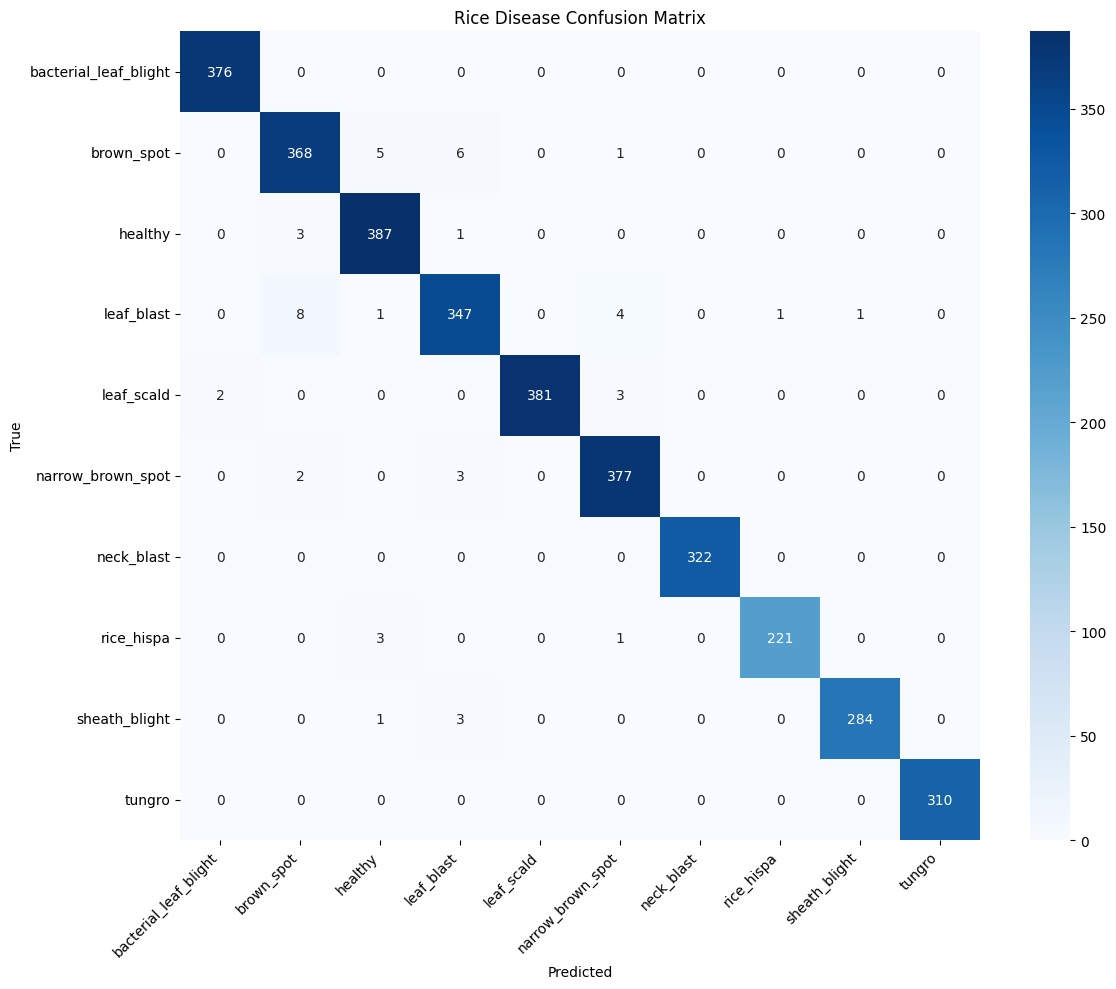

Found 3422 images belonging to 10 classes.
214/214 ━━━━━━━━━━━━━━━━━━━━ 116s 538ms/step
214/214 ━━━━━━━━━━━━━━━━━━━━ 116s 538ms/step
Classification Report:
                       precision    recall  f1-score   support

bacterial_leaf_blight       0.99      1.00      1.00       376
           brown_spot       0.97      0.97      0.97       380
              healthy       0.97      0.99      0.98       391
           leaf_blast       0.96      0.96      0.96       362
           leaf_scald       1.00      0.99      0.99       386
    narrow_brown_spot       0.98      0.99      0.98       382
           neck_blast       1.00      1.00      1.00       322
           rice_hispa       1.00      0.98      0.99       225
        sheath_blight       1.00      0.99      0.99       288
               tungro       1.00      1.00      1.00       310

             accuracy                           0.99      3422
            macro avg       0.99      0.99      0.99      3422
         weighted avg  

C:\Users\Vincent Hernandez\AppData\Local\Temp\ipykernel_16552\32550299.py:170: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10")


Saved ROC curve to c:\Users\Vincent Hernandez\Projects\Django-agriscan\AgriScan\mysite\models\roc_curve.png


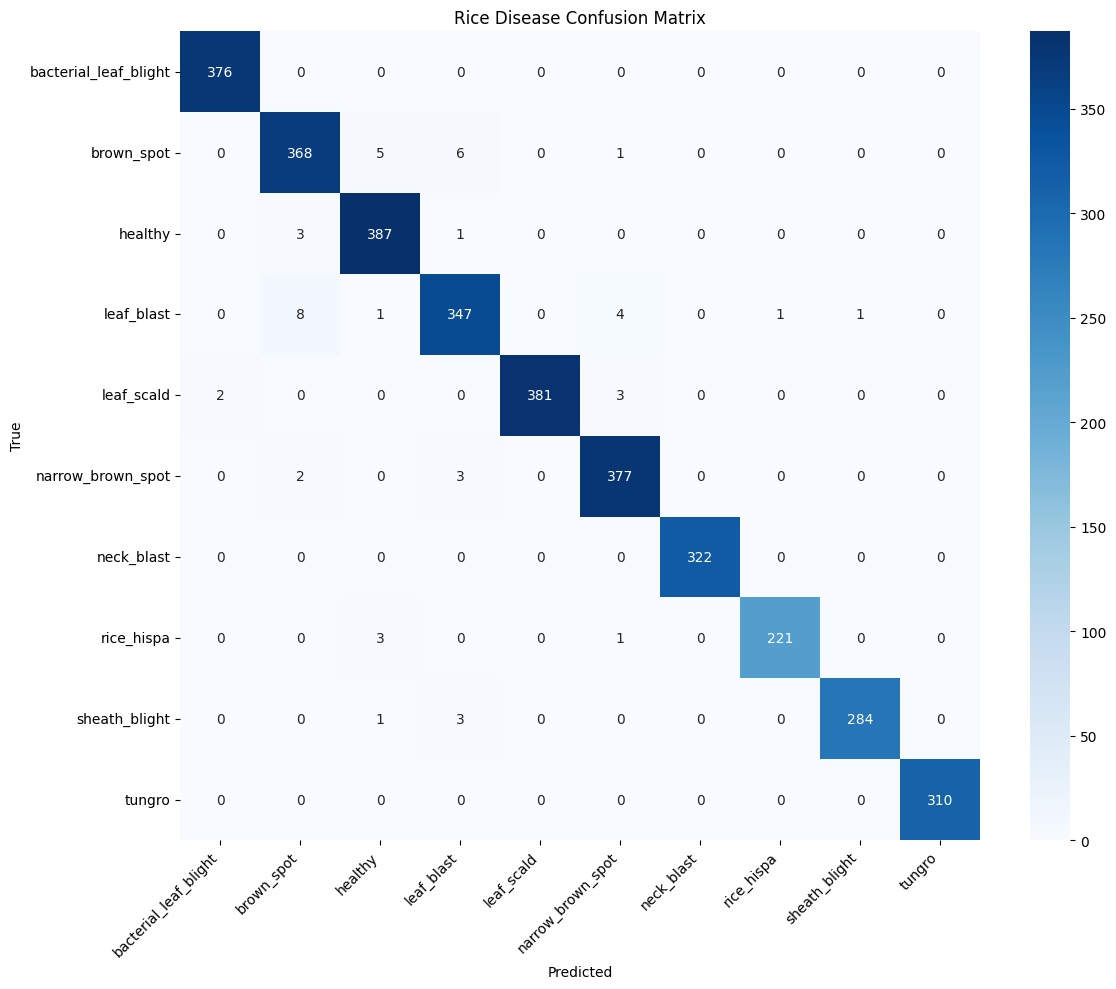

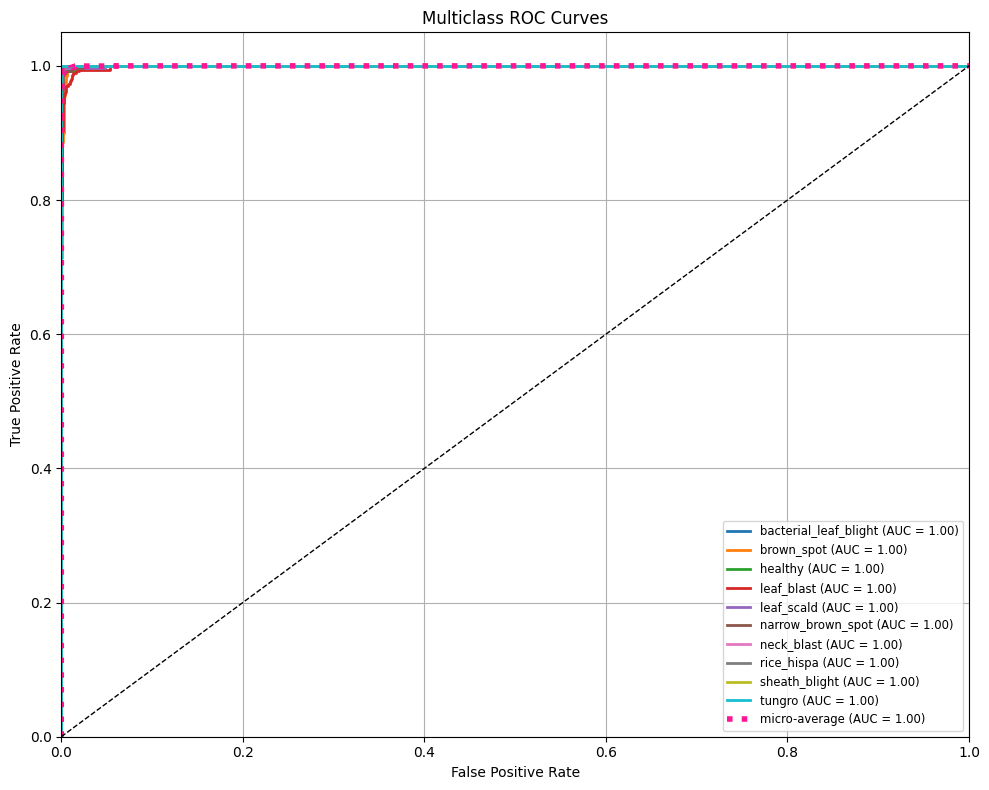

In [5]:
# src/evaluate.py
from __future__ import annotations

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

try:
    THIS_DIR = Path(__file__).resolve().parent
except NameError:
    # __file__ is not defined when running inside a Jupyter notebook or interactive shells.
    # Fall back to the current working directory so the notebook can run.
    THIS_DIR = Path.cwd()
BASE_DIR = THIS_DIR.parent
DATASET_DIR = BASE_DIR / "dataset"
MODELS_DIR = BASE_DIR / "models"

TEST_DIR = DATASET_DIR / "test"
MODEL_PATH = MODELS_DIR / "rice_disease_model.h5"
CLASS_MAP_PATH = MODELS_DIR / "class_names.json"
CONFUSION_FIG_PATH = MODELS_DIR / "confusion_matrix.png"
ROC_FIG_PATH = MODELS_DIR / "roc_curve.png"

IMG_SIZE = (224, 224)
BATCH = 16


def _load_class_names():
    if not CLASS_MAP_PATH.exists():
        raise FileNotFoundError(f"Missing class map at {CLASS_MAP_PATH}")
    with CLASS_MAP_PATH.open("r", encoding="utf-8") as fp:
        data = json.load(fp)
    if isinstance(data, dict) and "labels" in data:
        labels = data["labels"]
    elif isinstance(data, list):
        labels = data
    else:
        labels = [label for _, label in sorted((int(k), v) for k, v in data.items())]
    return labels


def main():
    if not TEST_DIR.exists():
        raise FileNotFoundError(f"Missing test directory at {TEST_DIR}")
    class_names = _load_class_names()
    model = load_model(MODEL_PATH)

    test_gen = ImageDataGenerator(rescale=1.0 / 255.0)
    test_data = test_gen.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH,
        class_mode="categorical",
        shuffle=False,
    )

    predictions = model.predict(test_data)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_data.classes

    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)

    # Per-class accuracy (recall) -- handle zero-support classes safely
    n_classes = len(class_names)
    class_acc = np.zeros(n_classes, dtype=float)
    for i in range(n_classes):
        support = cm[i].sum()
        class_acc[i] = cm[i, i] / support if support > 0 else float('nan')

    # Format per-class accuracies to 8 decimal places to match expected output precision
    class_acc_formatted = [float(f"{a:.8f}") if not np.isnan(a) else None for a in class_acc]
    print("Accuracy for each class:")
    print(class_acc_formatted)

    avg_acc = float(np.nanmean(class_acc)) if np.any(~np.isnan(class_acc)) else float('nan')
    overall_acc = float(np.trace(cm) / np.sum(cm)) if np.sum(cm) > 0 else float('nan')
    # Print averages/overall with two-decimal precision (matches provided sample)
    print(f"Average accuracy: {avg_acc:.2f}")
    print(f"Overall accuracy: {overall_acc:.2f}")
    print(f"Score: {overall_acc:.2f}")

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues",
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Rice Disease Confusion Matrix")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(CONFUSION_FIG_PATH, dpi=300)
    print(f"Saved confusion matrix to {CONFUSION_FIG_PATH}")

    # ROC AUC (supports multiclass using one-vs-rest)
    try:
        y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
    except Exception:
        # fallback: create one-hot manually
        y_true_bin = np.zeros((len(y_true), n_classes))
        for i, label in enumerate(y_true):
            y_true_bin[i, label] = 1

    # Ensure predictions shape matches
    if predictions.shape[1] != n_classes:
        raise ValueError(f"Prediction dimensionality {predictions.shape[1]} != number of classes {n_classes}")

    # Compute ROC AUC scores
    if n_classes == 2:
        # binary case: use positive class probabilities
        y_score = predictions[:, 1]
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        print(f"ROC AUC (binary): {roc_auc:.4f}")
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
        plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Receiver Operating Characteristic")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.savefig(ROC_FIG_PATH, dpi=300)
        print(f"Saved ROC curve to {ROC_FIG_PATH}")
    else:
        # multiclass: compute ROC curve and ROC area for each class
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], predictions[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        # Compute micro-average ROC curve and ROC area
        fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), predictions.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

        # Macro-average AUC using sklearn function
        try:
            auc_macro = roc_auc_score(y_true_bin, predictions, average="macro", multi_class="ovr")
            auc_micro = roc_auc_score(y_true_bin, predictions, average="micro", multi_class="ovr")
        except Exception:
            auc_macro = np.mean([roc_auc[i] for i in range(n_classes)])
            auc_micro = roc_auc["micro"]

        print(f"ROC AUC (macro): {auc_macro:.4f}")
        print(f"ROC AUC (micro): {auc_micro:.4f}")

        # Plot all ROC curves
        plt.figure(figsize=(10, 8))
        colors = plt.cm.get_cmap("tab10")
        for i, color in zip(range(n_classes), colors.colors):
            plt.plot(fpr[i], tpr[i], color=color, lw=2,
                     label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

        plt.plot(fpr["micro"], tpr["micro"],
                 label=f"micro-average (AUC = {roc_auc['micro']:.2f})",
                 color="deeppink", linestyle=":", linewidth=4)

        plt.plot([0, 1], [0, 1], "k--", lw=1)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Multiclass ROC Curves")
        plt.legend(loc="lower right", fontsize="small")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(ROC_FIG_PATH, dpi=300)
        print(f"Saved ROC curve to {ROC_FIG_PATH}")


if __name__ == "__main__":
    main()
